<a href="https://colab.research.google.com/github/AdamHopkinss/DD2365/blob/main/kopia_av_current1_project_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Euler equations for compressible flow**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Euler equations using FEM, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [1]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden,

# Copyright (C) 2021 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License v2.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [2]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Euler equations take the form

$
\begin{eqnarray}
\dot \rho + \nabla \cdot (u \rho) = 0, \\
\dot m + \nabla \cdot (u m) + \nabla p = f, \\
\dot E + \nabla \cdot (u E) + \nabla \cdot(up)= 0,
\end{eqnarray}
$

together with suitable initial and boundary conditions.

Here velocity is given by

$u = \frac{m}{\rho},$

and for a perfect gas, the pressure is given by

$p = (\gamma - 1)(E-\frac{\vert u\vert^2}{2}),$

where $\gamma = 1.4$ is the specific heat ratio for air, and we get the temperature,

$T = \frac{E}{\rho} - \frac{\vert u\vert^2}{2},$

the speed of sound,

$\sqrt{\gamma(\gamma-1)T},$

and the Mach number,

$M = \frac{\vert u\vert }{c}.$

Here we present a FEniCS implementation of a stabilized finite element method to solve the Euler equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

# **Method**

**Define domain and mesh**

In [3]:
def create_geometry_and_mesh(L=120.0, H=80.0, rc=9.0, resolution=32, refine_levels=1):
    xc = 0.5 * L
    yc = 0.5 * H

    # Domain with circular hole
    mesh = generate_mesh(Rectangle(Point(0.0, 0.0), Point(L, H)) - Circle(Point(xc, yc), rc), resolution)

    for _ in range(refine_levels):
        cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
        cell_marker.set_all(False)
        for cell in cells(mesh):
            if cell.midpoint().distance(Point(xc, yc)) < 2 * rc:
                cell_marker[cell] = True
        mesh = refine(mesh, cell_marker)

    return mesh, xc, yc, rc

# Boundary markers
def mark_boundaries(mesh, L, H):
    class Left(SubDomain):
        def inside(self, x, on_boundary):
            return near(x[0], 0.0) and on_boundary
    class Right(SubDomain):
        def inside(self, x, on_boundary):
            return near(x[0], L) and on_boundary
    class Lower(SubDomain):
        def inside(self, x, on_boundary):
            return near(x[1], 0.0) and on_boundary
    class Upper(SubDomain):
        def inside(self, x, on_boundary):
            return near(x[1], H) and on_boundary
    class ObjectBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and (
                not near(x[0], 0.0) and not near(x[0], L) and
                not near(x[1], 0.0) and not near(x[1], H)
            )

    boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundaries.set_all(0)

    Left().mark(boundaries, 1)
    Right().mark(boundaries, 2)
    Lower().mark(boundaries, 3)
    Upper().mark(boundaries, 4)
    obj_bdry = ObjectBoundary()
    obj_bdry.mark(boundaries, 5)

    ds = Measure("ds", domain=mesh, subdomain_data=boundaries)
    return boundaries, ds, obj_bdry


# refining mesh where the shock sensor is large
def adapt_mesh_by_sensor(sensor, mesh, threshold=0.3):
    cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
    cell_marker.set_all(False)
    sensor_values = sensor.vector().get_local()
    dofmap = sensor.function_space().dofmap()
    for cell in cells(mesh):
        dofs = dofmap.cell_dofs(cell.index())
        if np.max(sensor_values[dofs]) > threshold:
            cell_marker[cell] = True

    return refine(mesh, cell_marker)

**Define finite element approximation spaces**

In [4]:
def make_function_spaces(mesh):
    R = FunctionSpace(mesh, "CG", 1)
    V = VectorFunctionSpace(mesh, "CG", 1)
    Q = FunctionSpace(mesh, "CG", 1)
    return R, V, Q

def make_boundary_conditions(R, V, Q, r_in, m_in, E_in, L, H):
    class DirichletBoundaryLower(SubDomain):
        def inside(self, x, on_boundary): return on_boundary and near(x[1], 0.0)
    class DirichletBoundaryUpper(SubDomain):
        def inside(self, x, on_boundary): return on_boundary and near(x[1], H)
    class DirichletBoundaryLeft(SubDomain):
        def inside(self, x, on_boundary): return on_boundary and near(x[0], 0.0)
    class DirichletBoundaryRight(SubDomain):
        def inside(self, x, on_boundary): return on_boundary and near(x[0], L)
    class ObjectBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and (
                not near(x[0], 0.0) and not near(x[0], L) and
                not near(x[1], 0.0) and not near(x[1], H)
                )


    dbc_left = DirichletBoundaryLeft()
    dbc_upper = DirichletBoundaryUpper()
    dbc_lower = DirichletBoundaryLower()
    dbc_object = ObjectBoundary()

    bcm = [
        DirichletBC(V.sub(0), m_in[0], dbc_left),
        DirichletBC(V.sub(1), Constant(0.0), dbc_left),
        DirichletBC(V.sub(0), Constant(0.0), dbc_upper),
        DirichletBC(V.sub(1), Constant(0.0), dbc_upper),
        DirichletBC(V.sub(0), Constant(0.0), dbc_lower),
        DirichletBC(V.sub(1), Constant(0.0), dbc_lower),
        DirichletBC(V, Constant((0.0, 0.0)), dbc_object)
    ]
    bcr = [DirichletBC(R, r_in, dbc_left)]
    bcE = [DirichletBC(Q, E_in, dbc_left)]
    return bcm, bcr, bcE

### Defining the Meteor


In [5]:
# Material density in kg/m³ (representing meteor compositions)
def make_meteor(rc):
  materials = {
      "iron": 7870.0,                      # iron meteor
      "ice": 917.0,                        # pure ice
      "stone": 3500.0,                     # rocky meteor
      "mixed": 0.6 * 7870.0 + 0.4 * 917.0  # 60% iron, 40% ice
  }

  # Select composition
  material_choice = "iron"
  object_density = materials[material_choice]

  # Assumed depth of the 3D object (m)
  object_depth = 1.0

  # Compute area of the circular object (2D projection)
  object_area = np.pi * rc**2  # m²

  # Compute volume and mass
  object_volume = object_area * object_depth  # m³
  mass_object = object_density * object_volume  # kg

  print(f"Material: {material_choice}, Mass: {mass_object/1000:.2f} tons")
  return mass_object

### U.S. Standard Atmosphere Model (up to 85 km)

The atmospheric inflow conditions are computed using a piecewise approximation of the U.S. Standard Atmosphere 1976. Each layer is defined by a base altitude $h_b$, lapse rate $L_b$, base temperature $T_b$, and base pressure $p_b$.

**Temperature** is computed via:

$$
T(h) = T_b + L_b (h - h_b)
$$

**Pressure** is computed using the barometric formula:

- For gradient layers ($L_b \ne 0$):

$$
p(h) = p_b \left( \frac{T(h)}{T_b} \right)^{-g_0 / (R L_b)}
$$

- For isothermal layers ($L_b = 0$):

$$
p(h) = p_b \exp\left( \frac{-g_0 (h - h_b)}{R T_b} \right)
$$

**Density** is then obtained from the ideal gas law:

$$
\rho(h) = \frac{p(h)}{R T(h)}
$$

**Total energy** per unit volume at altitude $h$ and inflow velocity $u$ is:

$$
E(h, u) = \rho(h) \left( \frac{1}{2} u^2 + \frac{R T(h)}{\gamma - 1} \right)
$$

where:

- $R = 287.05 \, \text{J/(kg·K)}$ is the specific gas constant for air  
- $\gamma = 1.4$ is the specific heat ratio  
- $g_0 = 9.80665 \, \text{m/s}^2$ is standard gravity


In [6]:
# Constants
R_air = 287.05      # J / (kg*K)
g0 = 9.80665    # m/s^2
gamma = 1.4

# Atmospheric layers: [Altitude [m], Temperature lapse rate [K/m], Temperature [K], Pressure [Pa]]
# Based on U.S. Standard Atmosphere 1976
atmo_layers = [
    (0,     -0.0065, 288.15, 101325.0),
    (11000,  0.0,    216.65, 22632.1),
    (20000,  0.0010, 216.65, 5474.89),
    (32000,  0.0028, 228.65, 868.019),
    (47000,  0.0,    270.65, 110.906),
    (51000, -0.0028, 270.65, 66.9389),
    (71000, -0.0020, 214.65, 3.95642),
    (84852,  0.0,    186.8673, 0.3734),  # Edge of model (about 85 km)
]


def inflow_temperature(h):
    for i in range(len(atmo_layers) - 1):
        h_b, L_b, T_b, _ = atmo_layers[i]
        h_t = atmo_layers[i+1][0]
        if h >= h_b and h < h_t:
            return T_b + L_b * (h - h_b)
    # If above last layer
    return atmo_layers[-1][2]


def inflow_density(h):
    """Density at altitude h [m] using barometric formula with temperature gradient"""
    for i in range(len(atmo_layers) - 1):
        h_b, L_b, T_b, p_b = atmo_layers[i]
        h_t = atmo_layers[i+1][0]
        if h >= h_b and h < h_t:
            if L_b == 0.0:
                # Isothermal layer
                exponent = -g0 * (h - h_b) / (R_air * T_b)
                p = p_b * np.exp(exponent)
            else:
                # Gradient layer
                T = T_b + L_b * (h - h_b)
                exponent = -g0 / (R_air * L_b)
                p = p_b * (T / T_b) ** exponent
            rho = p / (R_air * inflow_temperature(h))
            return rho
    # If above last layer
    T = inflow_temperature(h)
    p = atmo_layers[-1][3] * np.exp(-g0 * (h - atmo_layers[-1][0]) / (R_air * T))
    rho = p / (R_air * T)
    return rho

def inflow_energy(h, v):      # Dependent on inflow velo. and altitude
    rho = inflow_density(h)
    T = inflow_temperature(h)
    return rho * (0.5 * v**2 + R_air * T / (gamma - 1))


**Define boundary conditions**

# **Results**

**Define variational problem**

### Adaptive Stabilization Parameters

We scale key stabilization terms with the local Mach number $\mathrm{Ma}$ to improve robustness across flow regimes:

- **SUPG stabilization:**
  $$
  C_1(\mathrm{Ma}) = 0.5 + 4.5 \cdot \frac{\mathrm{Ma}^2}{1 + \mathrm{Ma}^2}
  $$
  Smoothly increases from 0.5 (incompressible) to 5 (hypersonic), used in time/space stabilization.

- **Artificial viscosity:**
  $$
  C_{\text{stab}}(\mathrm{Ma}) = 1 + 15 \cdot \frac{\mathrm{Ma}}{1 + \mathrm{Ma}}
  $$
  Rises from 1 to ~16 to stabilize shocks via residual-based diffusion.

- **Penalty parameter:**
  $$
  C_\alpha(\mathrm{Ma}) = 50 + 750 \cdot \frac{\mathrm{Ma}}{1 + \mathrm{Ma}}
  $$
  Ramps from 50 to 800, strengthening boundary enforcement at higher speeds.


In [7]:
# Define variational problem
def initialize_solutions(R, V, Q):
    r0 = Function(R)
    m0 = Function(V)
    E0 = Function(Q)
    r1 = Function(R)
    m1 = Function(V)
    E1 = Function(Q)
    return r0, m0, E0, r1, m1, E1


def define_variational_forms(R, V, Q, r0, m0, E0, r1, m1, E1, dt, eps_cav, r_in, m_in, E_in, ds):
    r = TrialFunction(R)
    m = TrialFunction(V)
    E = TrialFunction(Q)
    d = TestFunction(R)
    v = TestFunction(V)
    q = TestFunction(Q)

    # Mean velocities for trapozoidal time stepping
    rm = 0.5*(r + r0)
    mm = 0.5*(m + m0)
    Em = 0.5*(E + E0)

    rm1 = 0.5*(r1 + r0)
    mm1 = 0.5*(m1 + m0)
    Em1 = 0.5*(E1 + E0)

    u0 = m0/(r0 + eps_cav)
    u1 = m1/(r1 + eps_cav)
    um1 = 0.5*(u1 + u0)

    # Perfect gas
    #gamma = 1.4 # specific heat ratio for air
    # Pressure
    p1 = (gamma - 1.0)*(E1 - 0.5*inner(m1,m1)/(r1 + eps_cav))

    # Temperature
    Temp = E1/(r1 + eps_cav) - 0.5*inner(u1, u1)


    # Speed of sound
    c = sqrt(gamma*(gamma-1.0)*Temp)

    # Mach number
    Mach = sqrt(inner(u1, u1))/c

    # Facet normal
    normal = FacetNormal(mesh)

    # Local mesh size
    h = CellDiameter(mesh);

    # Stabilization parameters
    u_mag = sqrt(dot(u1,u1))
    # C1 = 0.5
    from ufl_legacy import max_value, min_value
    C1 = 0.5 + 4.5 * (Mach**2 / (1 + Mach**2))
    d1 = C1 / (sqrt(1.0/dt**2 + max_value(u_mag, 10.0)**2/h**2)) # Streamline-upwind (SUPG)-like stabilization

    # Penalty boundary conditions
    # C_alpha = 1.0e2
    C_alpha = 50 + 750 * (Mach / (1 + Mach))  # smoothly ramps
    alpha = C_alpha/h

    # Residuals
    res_r = (rm1 - r0)/dt + div(u1)*r1 + inner(grad(r1), u1)
    res_m = (mm1 - m0)/dt + div(u1)*m1 + grad(m1)*u1 + grad(p1)

    # Improved energy residual (removed redundant pressure terms)
    flux_E = E1 * u1 + p1 * u1
    res_E = (Em1 - E0)/dt + div(flux_E)

    # Smagorinsky model (simplified)
    C_t = 1.0e-2

    # Shock sensor based on energy variation (Persson–Peraire-like)
    V_dg = FunctionSpace(mesh, 'DG', 0)

    # Project the gradient magnitude of E1
    grad_E1 = project(sqrt(inner(grad(E1), grad(E1))), V_dg)

    # Project E1 into DG space for stable normalization
    E1_dg = project(E1, V_dg)

    # Compute shock sensor value: |∇E| / E
    sensor_expr = grad_E1 / (E1_dg + 1e-8)
    sensor_E = project(sensor_expr, V_dg)

    # Clip overly large sensor values (optional safety)
    sensor_E.vector().set_local(np.minimum(sensor_E.vector().get_local(), 100.0))

    # Smooth cutoff: sensor / (1 + sensor)
    cutoff_expr = sensor_E / (sensor_E + 1.0)
    sensor_cut = project(cutoff_expr, V_dg)  # smooth activation of viscosity

    # Mach-adaptive viscosity constant (same as before)
    C_stab = 1.0 + 15 * (Mach / (1 + Mach))

    # Local artificial viscosity (only where shock sensor is active)
    nu_r = C_stab * h**2 * sqrt(res_r**2) / r_in * sensor_cut
    nu_m = C_stab * h**2 * sqrt(inner(res_m, res_m)) / m_in[0] * sensor_cut
    nu_E = C_stab * h**2 * sqrt(res_E**2) / E_in * sensor_cut


    # Density variational equation on residual form
    Fr = inner((r - r0)/dt, d)*dx - inner(rm*um1, grad(d))*dx \
        + nu_r * inner(grad(rm), grad(d))*dx \
        + inner(dot(um1, normal)*r_in, d)*ds(1) \
        + inner(dot(um1, normal)*rm, d)*ds(2) \
        + d1*inner((r - r0)/dt + div(u1)*rm + inner(grad(rm), u1), dot(grad(d), u1))*dx

    ar = lhs(Fr)
    Lr = rhs(Fr)

    m_in_vec = as_vector(m_in)
    # Momentum variational equation on residual form
    Fm = inner((m - m0)/dt, v)*dx - inner(outer(mm,um1), grad(v))*dx - p1*div(v)*dx \
            + nu_m * inner(grad(mm), grad(v))*dx \
            + alpha*(inner(dot(mm,normal), dot(v,normal)))*ds(5) \
            + (dot(u1, normal)*inner(m_in_vec, v))*ds(1) \
            + (dot(u1, normal)*inner(mm, v))*ds(2) \
            + d1*inner((m - m0)/dt + div(u1)*mm + grad(mm)*u1 + grad(p1), grad(v)*u1)*dx

    am = lhs(Fm)
    Lm = rhs(Fm)

    # Density variational equation on residual form
    FE = inner((E - E0)/dt, q)*dx - inner(Em*um1, grad(q))*dx \
        + nu_E * inner(grad(Em), grad(q))*dx \
        + inner(dot(um1, normal)*E_in, q)*ds(1) \
        + inner(dot(um1, normal)*Em, q)*ds(2) \
        + d1*inner((E - E0)/dt + div(flux_E), dot(grad(q), u1))*dx

    aE = lhs(FE)
    LE = rhs(FE)
    return ar, Lr, am, Lm, aE, LE, sensor_cut


#### Without stabalizing terms

In [8]:
def define_variational_forms_noStab(R, V, Q, r0, m0, E0, r1, m1, E1, dt, eps_cav, r_in, m_in, E_in, ds):
    r = TrialFunction(R)
    m = TrialFunction(V)
    E = TrialFunction(Q)
    d = TestFunction(R)
    v = TestFunction(V)
    q = TestFunction(Q)
    m_in_vec = as_vector(m_in)

    u0 = m0 / (r0 + eps_cav)
    u1 = m1 / (r1 + eps_cav)
    um1 = 0.5 * (u1 + u0)

    rm = 0.5 * (r + r0)
    mm = 0.5 * (m + m0)
    Em = 0.5 * (E + E0)

    p1 = (gamma - 1.0) * (E1 - 0.5 * inner(m1, m1) / (r1 + eps_cav))
    flux_E = E1 * u1 + p1 * u1

    normal = FacetNormal(r1.function_space().mesh())

    # Mass equation
    Fr = inner((r - r0) / dt, d) * dx - inner(rm * um1, grad(d)) * dx \
         + inner(dot(um1, normal) * r_in, d) * ds(1) \
         + inner(dot(um1, normal) * rm, d) * ds(2)

    ar = lhs(Fr)
    Lr = rhs(Fr)

    # Momentum equation
    Fm = inner((m - m0) / dt, v) * dx \
         - inner(outer(mm, um1), grad(v)) * dx \
         - p1 * div(v) * dx \
         + (dot(u1, normal) * inner(m_in_vec, v)) * ds(1) \
         + (dot(u1, normal) * inner(mm, v)) * ds(2)

    am = lhs(Fm)
    Lm = rhs(Fm)

    # Energy equation
    FE = inner((E - E0) / dt, q) * dx \
         - inner(Em * um1, grad(q)) * dx \
         + inner(dot(um1, normal) * E_in, q) * ds(1) \
         + inner(dot(um1, normal) * Em, q) * ds(2)

    aE = lhs(FE)
    LE = rhs(FE)

    return ar, Lr, am, Lm, aE, LE


**Compute force on boundary**

In [9]:
def define_force_computation(mesh, m1, r1, p1, eps_cav, ds, rc, m_in, r_in, dbc_objects):
    # Define the indicator function for the force
    V_psi = VectorFunctionSpace(mesh, "CG", 1)
    psi = Function(V_psi)
    psi.vector()[:] = 0.0

    bc_psi = DirichletBC(V_psi, Constant((psi_x, psi_y)), dbc_objects)
    bc_psi.apply(psi.vector())

    # Velocity
    u1 = m1 / (r1 + eps_cav)

    force_normal = FacetNormal(mesh)
    Force_pressure = inner(force_normal, psi) * p1 * ds(5)

    u_in = m_in[0] / r_in
    normalization = -2.0 / (2.0 * rc * u_in * u_in)

    return Force_pressure, normalization

**Set plotting variables and open export files**

In [10]:
def setup_output(plot_dir="results-NS", plot_freq=50, start_sample_time=1.0):
    # Ensure directory exists
    import os
    if not os.path.exists(plot_dir):
        os.makedirs(plot_dir)

    # Output files
    file_r = File(f"{plot_dir}/r.pvd")
    file_m = File(f"{plot_dir}/m.pvd")
    file_E = File(f"{plot_dir}/E.pvd")
    file_Mach = File(f"{plot_dir}/Mach.pvd")

    # Initialize arrays and counters
    force_array = np.array([], dtype=float)
    force_array_pressure = np.array([], dtype=float)
    time_array = np.array([], dtype=float)
    plot_time = 0.0

    return {
        "file_r": file_r,
        "file_m": file_m,
        "file_E": file_E,
        "file_Mach": file_Mach,
        "force_array": force_array,
        "force_array_pressure": force_array_pressure,
        "time_array": time_array,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "start_sample_time": start_sample_time
    }

### Time stepping algorithm

#### Simulating for Initial Conditions (IC)

In [11]:
def plot_solution(r, m, E, Q, eps_cav, t, gamma=1.4):
    u = m / (r + eps_cav)
    velocity_mag = project(sqrt(inner(u, u)), Q)
    Temp = E / (r + eps_cav) - 0.5 * inner(u, u)
    c = sqrt(gamma * (gamma - 1.0) * abs(Temp))
    Mach_number = project(sqrt(inner(u, u)) / (c + eps_cav), Q)
    Temp_proj = project(Temp, Q)

    print(f"[PLOT] t = {t:.2f} s")

    plt.figure()
    im = plot(r, title=f"Density (t = {t:.2f}s)")
    plt.colorbar(im)

    plt.figure()
    im = plot(m, title=f"Momentum (t = {t:.2f}s)")
    plt.colorbar(im)

    plt.figure()
    im = plot(E, title=f"Total Energy (t = {t:.2f}s)")
    plt.colorbar(im)

    plt.figure()
    im = plot(u, title=f"Velocity (t = {t:.2f}s)")
    plt.colorbar(im)

    plt.figure()
    im = plot(velocity_mag, title=f"Velocity Magnitude (t = {t:.2f}s)")
    plt.colorbar(im)

    plt.figure()
    im = plot(Mach_number, title=f"Mach Number (t = {t:.2f}s)")
    plt.colorbar(im)

    plt.figure()
    im = plot(Temp_proj, title=f"Temperature (t = {t:.2f}s)")
    plt.colorbar(im)

    plt.show()


In [12]:
from tqdm import tqdm

def update_dt(velocity, mesh, cfl=0.5):
    """Compute time step using CFL condition."""
    return Constant(cfl * mesh.hmin() / (velocity + 1e-8))


def initialize_inflow_fields(r0, m0, E0, altitude, velocity):
    """Set initial inflow state from atmospheric model."""
    rho_init = inflow_density(altitude)
    E_init = inflow_energy(altitude, velocity)
    r0.interpolate(Constant(rho_init))
    m0.interpolate(Constant((rho_init * velocity, 0.0)))
    E0.interpolate(Constant(E_init))

    # Plot initial fields
    plt.figure(); plot(r0, title="Density"); plt.colorbar()
    plt.figure(); plot(m0, title="Momentum"); plt.colorbar()
    plt.figure(); plot(E0, title="Total energy"); plt.colorbar()
    return rho_init, E_init


def ramp_up_to_velocity(r0, m0, E0, r1, m1, E1,
                        R, V, Q,
                        V_dg, bcr, bcm, bcE,
                        ar, Lr, am, Lm, aE, LE, Force_pressure,
                        m_in, r_in, E_in, target_velocity, altitude,
                        mesh, dt, num_nnlin_iter, gamma, rc, ds,
                        ramp_velocity_init, ramping,
                        plot_interval=0.3):
    print("\n[INFO] Starting velocity ramp-up...")
    pbar = tqdm(total=target_velocity, desc="Ramp-up", unit="m/s")

    # Constants
    print_velocity = 0.0
    eps_cav = 1e-8
    rho_min, E_min = 1e-6, 1e-6
    ramp_velocity = ramp_velocity_init
    ramping = ramping
    t = float(dt)
    plot_time = 0.0
    use_stab = False    # Flag
    ar, Lr, am, Lm, aE, LE = define_variational_forms_noStab(
        R, V, Q, r0, m0, E0, r1, m1, E1, dt, eps_cav, r_in, m_in, E_in, ds
        )
    bar_length = 40
    sensor_cut = project(Constant(0.0), V_dg)  # off initially
    while ramp_velocity < target_velocity:

        if (not use_stab) and ramp_velocity >= 500:
            print("[INFO] Enabling shock sensor and stabilized forms.")
            # Redefine forms with sensor support
            ar, Lr, am, Lm, aE, LE, sensor_cut = define_variational_forms(
                R, V, Q, r0, m0, E0, r1, m1, E1, dt, eps_cav,
                r_in, as_vector(m_in), E_in, ds
            )
            use_stab = True

        elif not use_stab:
            # Use unstabilized forms
            ar, Lr, am, Lm, aE, LE = define_variational_forms_noStab(
                R, V, Q, r0, m0, E0, r1, m1, E1, dt, eps_cav,
                r_in, as_vector(m_in), E_in, ds
            )
            sensor_cut.assign(project(Constant(0.0), V_dg))  # stay off

        # Inflow state
        rho_in = inflow_density(altitude)
        E_inflow = inflow_energy(altitude, ramp_velocity)
        T_inflow = inflow_temperature(altitude)
        v_in = ramp_velocity
        p_in = (gamma - 1.0) * (E_inflow / rho_in - 0.5 * v_in**2)

        # Update inflow boundary Constants
        r_in.assign(rho_in)
        m_in[0].assign(rho_in * ramp_velocity)
        E_in.assign(E_inflow)

        # Update time step
        dt.assign(update_dt(ramp_velocity, mesh))
        current_dt = float(dt)

        # Set initial guess
        r1.assign(r0); m1.assign(m0); E1.assign(E0)

        # Clamp before solve
        r1.vector().set_local(np.maximum(r1.vector().get_local(), rho_min))
        E1.vector().set_local(np.clip(E1.vector().get_local(), E_min, 1e6))

        # Newton loop
        for k in range(num_nnlin_iter):
            if not use_stab and k == 0:
                sensor_cut.assign(project(Constant(0.0), V_dg))  # disable sensor for stability

            try:
                for (A, b, sol, bc_list, label) in [
                    (assemble(ar), assemble(Lr), r1, bcr, "rho"),
                    (assemble(am), assemble(Lm), m1, bcm, "momentum"),
                    (assemble(aE), assemble(LE), E1, bcE, "energy")]:
                    [bc.apply(A, b) for bc in bc_list]
                    [bc.apply(sol.vector()) for bc in bc_list]
                    solve(A, sol.vector(), b, "bicgstab", "default")

            except RuntimeError as e:
                print(f"[ERROR] Linear solve failed at k={k} for {label}: {str(e)}")
                raise

            # Clamp again after solve
            r1.vector().set_local(np.maximum(r1.vector().get_local(), rho_min))
            E1.vector().set_local(np.clip(E1.vector().get_local(), E_min, 1e6))

            # Shock sensor
            grad_E1 = project(sqrt(inner(grad(E1), grad(E1))), V_dg)
            E1_dg = project(E1, V_dg)
            sensor_expr = grad_E1 / (E1_dg + 1e-8)
            sensor_E = project(sensor_expr, V_dg)
            sensor_E.vector().set_local(np.minimum(sensor_E.vector().get_local(), 100.0))
            sensor_cut.assign(project(sensor_E / (sensor_E + 1.0), V_dg))

            # Under-relaxation
            omega = 0.3
            r1.vector()[:] = (1 - omega) * r0.vector() + omega * r1.vector()
            m1.vector()[:] = (1 - omega) * m0.vector() + omega * m1.vector()
            E1.vector()[:] = (1 - omega) * E0.vector() + omega * E1.vector()

            if Q is not None and float(t) >= plot_time:
                do_plot = True
                plot_time += plot_interval
            else:
                do_plot = False

        # Drag force and state update
        D = float(assemble(Force_pressure))
        # Update time, velocity, progress
        r0.assign(r1); m0.assign(m1); E0.assign(E1)
        t += current_dt
        ramp_velocity += ramping * current_dt

        # ✅ Update progress bar
        progress = min(ramp_velocity / target_velocity, 1.0)
        block = int(bar_length * progress)
        bar = "█" * block + "-" * (bar_length - block)
        print(f"\r[INFO] Ramp-up: |{bar}| {ramp_velocity:.0f} m/s / {target_velocity:.0f} m/s | dt = {current_dt:.2e}", end="")

        # ✅ Then plot (after the bar prints)
        if do_plot:
            plot_solution(r1, m1, E1, Q, eps_cav, t, gamma)

    pbar.close()
    return float(ramp_velocity), float(t)


### Main Simulation with calculated IC

In [13]:
def run_reentry_simulation(
    altitude, target_altitude, velocity, t,
    r0, m0, E0, r1, m1, E1,
    bcr, bcm, bcE,
    ar, Lr, am, Lm, aE, LE, dt,
    V_dg, sensor_cut, Force_pressure,
    m_in, r_in, E_in,
    num_nnlin_iter, mass_object, gamma,
    Q, mesh, rc, ds,
    plot_interval=0.3, adapt_interval=1.0
):
    rho_min, E_min = 1e-6, 1e-6
    eps_cav = 1e-8
    last_plot = float(t)
    last_adapt = float(t)

    while altitude > target_altitude:
        # Update inflow
        rho_inflow = inflow_density(altitude)
        E_inflow = inflow_energy(altitude, velocity)
        m_in[0].assign(rho_inflow * velocity)
        r_in.assign(rho_inflow)
        E_in.assign(E_inflow)

        dt.assign(update_dt(velocity, mesh))
        current_dt = float(dt)

        if r0.vector().min() <= 0 or E0.vector().min() <= 0:
            print("[ERROR] Nonphysical state detected. Stopping.")
            break

        # Newton iteration
        # Clamp unphysical values
        r1.vector().set_local(np.maximum(r1.vector().get_local(), 1e-6))
        E1.vector().set_local(np.clip(E1.vector().get_local(), 1e-6, 1e6))
        for k in range(num_nnlin_iter):
            solve(assemble(ar), r1.vector(), assemble(Lr), "bicgstab", "default")
            solve(assemble(am), m1.vector(), assemble(Lm), "bicgstab", "default")
            solve(assemble(aE), E1.vector(), assemble(LE), "bicgstab", "default")

            r1.vector().set_local(np.maximum(r1.vector().get_local(), rho_min))
            E1.vector().set_local(np.maximum(E1.vector().get_local(), E_min))

            # Shock sensor update
            grad_E = project(sqrt(inner(grad(E1), grad(E1))), V_dg)
            E1_dg = project(E1, V_dg)
            sensor_expr = grad_E / (E1_dg + 1e-8)
            sensor_E = project(sensor_expr, V_dg)
            sensor_E.vector().set_local(np.minimum(sensor_E.vector().get_local(), 100.0))
            sensor_cut.assign(project(sensor_E / (sensor_E + 1.0), V_dg))

            # Under-relaxation
            omega = 0.3
            r1.vector()[:] = (1 - omega)*r0.vector() + omega*r1.vector()
            m1.vector()[:] = (1 - omega)*m0.vector() + omega*m1.vector()
            E1.vector()[:] = (1 - omega)*E0.vector() + omega*E1.vector()

        # Physics updates
        D = float(assemble(Force_pressure))
        acceleration = (mass_object * g0 - D) / mass_object
        velocity += acceleration * current_dt
        altitude -= velocity * current_dt + 0.5 * acceleration * current_dt**2

        print(f"[INFO] t={t:.2f}s, altitude={altitude:.1f} m, velocity={velocity:.2f} m/s")

        # Plot every 0.3 seconds
        if float(t) - last_plot >= plot_interval:
            plot_solution(r1, m1, E1, Q, eps_cav, t, gamma)
            last_plot = float(t)

        # Adapt mesh every 1.0 seconds based on sensor
        if float(t) - last_adapt >= adapt_interval:
            print("[INFO] Adapting mesh based on shock sensor...")
            new_mesh = adapt_mesh_by_sensor(sensor_cut, mesh, threshold=0.2)
            mesh.assign(new_mesh)

            # Rebuild everything that depends on mesh
            R, V, Q = make_function_spaces(mesh)
            r0, m0, E0, r1, m1, E1 = initialize_solutions(R, V, Q)
            V_dg = FunctionSpace(mesh, "DG", 0)
            boundaries, ds, obj_boundary = mark_boundaries(mesh, L, H)
            bcm, bcr, bcE = make_boundary_conditions(R, V, Q, r_in, m_in, E_in, L, H)
            ar, Lr, am, Lm, aE, LE, sensor_cut = define_variational_forms(
                R, V, Q, r0, m0, E0, r1, m1, E1, dt, eps_cav, r_in, m_in, E_in, ds)
            Force_pressure, _ = define_force_computation(
                mesh, m1, r1, (gamma - 1.0)*(E1 - 0.5*inner(m1, m1)/(r1 + eps_cav)), eps_cav, ds, rc, m_in, r_in,
                AutoSubDomain(lambda x, on_b: on_b and boundaries.array() == 5))

            last_adapt = float(t)

        # Advance time
        r0.assign(r1); m0.assign(m1); E0.assign(E1)
        t += current_dt

    return velocity, altitude


Material: iron, Mass: 2002.67 tons


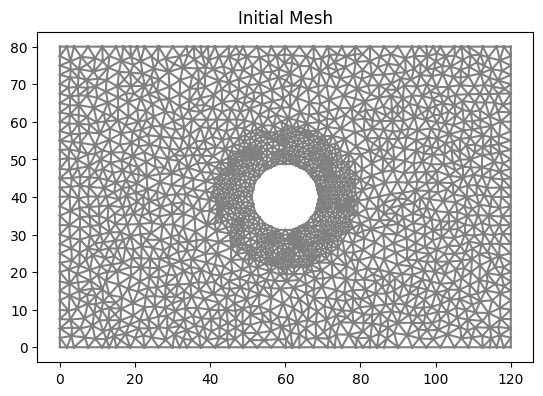

In [14]:
L, H, rc = 120.0, 80.0, 9
mesh, xc, yc, rc = create_geometry_and_mesh(L=L, H=H, rc=rc, resolution=32)
boundaries, ds, obj_boundary = mark_boundaries(mesh, L, H)

mass_object = make_meteor(rc)

plt.figure()
plot(mesh, title="Initial Mesh")
plt.show()

R, V, Q = make_function_spaces(mesh)
r0, m0, E0, r1, m1, E1 = initialize_solutions(R, V, Q)
V_dg = FunctionSpace(mesh, "DG", 0)



In [15]:
# DEFINE SIMULATION PARAMETERS
altitude = 30000.0            # Initial altitude [m]
target_altitude = 25000.0     # Target altitude to stop [m]
target_velocity = 11000.0     # Entry velocity [m/s]
num_nnlin_iter = 5            # Newton steps per time step

ramp_velocity_init = 100
ramping = 2000
# INTERPOLATE INITIAL CONDITIONS
rho_init = inflow_density(altitude)
E_init = inflow_energy(altitude, ramp_velocity_init)

r0.interpolate(Constant(rho_init))
m0.interpolate(Constant((rho_init * ramp_velocity_init, 0.0)))
E0.interpolate(Constant(E_init))

r1.assign(r0)
m1.assign(m0)
E1.assign(E0)

print("[DEBUG] Checking field ranges before defining forms:")
print("r0 min/max:", np.min(r0.vector().get_local()), np.max(r0.vector().get_local()))
print("m0 min/max:", np.min(m0.vector().get_local()), np.max(m0.vector().get_local()))
print("E0 min/max:", np.min(E0.vector().get_local()), np.max(E0.vector().get_local()))
print("[DEBUG] Checking field ranges before defining forms:")
print("r1 min/max:", np.min(r1.vector().get_local()), np.max(r1.vector().get_local()))
print("m1 min/max:", np.min(m1.vector().get_local()), np.max(m1.vector().get_local()))
print("E1 min/max:", np.min(E1.vector().get_local()), np.max(E1.vector().get_local()))

# CREATE CONSTANTS FOR INFLOW BOUNDARY
r_in = Constant(rho_init)
m_in_x = Constant(rho_init * ramp_velocity_init)
m_in_y = Constant(0.0)
m_in = [m_in_x, m_in_y]
E_in = Constant(E_init)

# SET INITIAL dt CONSTANT
dt = Constant(1e-4)

# DEFINE BOUNDARY CONDITIONS
bcm, bcr, bcE = make_boundary_conditions(R, V, Q, r_in, m_in, E_in, L, H)

# BUILD VARIATIONAL FORMS
ar, Lr, am, Lm, aE, LE, sensor_cut = define_variational_forms(
    R, V, Q, r0, m0, E0, r1, m1, E1, dt,
    eps_cav=1e-8, r_in=r_in, m_in=m_in, E_in=E_in, ds=ds
    )

# r1.vector().set_local(np.maximum(r1.vector().get_local(), 1e-6))
# E1.vector().set_local(np.maximum(E1.vector().get_local(), 1e-6))
# m1.vector().set_local(np.nan_to_num(m1.vector().get_local(), nan=0.0, posinf=0.0, neginf=0.0))


# FORCE FUNCTION (psi direction: horizontal drag)
psi_x, psi_y = 1.0, 0.0

Force_pressure, normalization = define_force_computation(
    mesh, m1, r1, (1.4 - 1.0)*(E1 - 0.5*inner(m1, m1)/(r1 + 1e-8)), 1e-8, ds, rc, m_in, r_in, obj_boundary
    )

# RAMP-UP TO FULL ENTRY VELOCITY
velocity, t = ramp_up_to_velocity(
    r0, m0, E0, r1, m1, E1,
    R, V, Q,
    V_dg, bcr, bcm, bcE,
    ar, Lr, am, Lm, aE, LE, Force_pressure,
    m_in, r_in, E_in, target_velocity, altitude,
    mesh, dt, num_nnlin_iter, gamma, rc, ds,
    ramp_velocity_init, ramping
)

# MAIN SIMULATION LOOP
velocity, altitude = run_reentry_simulation(
    altitude, target_altitude, velocity, t,
    r0, m0, E0, r1, m1, E1,
    bcr, bcm, bcE,
    ar, Lr, am, Lm, aE, LE, dt,
    V_dg, sensor_cut, Force_pressure,
    m_in, r_in, E_in,
    num_nnlin_iter, mass_object, gamma,
    Q, mesh, rc, ds,
    plot_interval=0.3, adapt_interval=1.0
    )



[DEBUG] Checking field ranges before defining forms:
r0 min/max: 0.018011828586567635 0.018011828586567635
m0 min/max: 0.0 1.8011828586567635
E0 min/max: 3019.6777715634175 3019.6777715634175
[DEBUG] Checking field ranges before defining forms:
r1 min/max: 0.018011828586567635 0.018011828586567635
m1 min/max: 0.0 1.8011828586567635
E1 min/max: 3019.6777715634175 3019.6777715634175

[INFO] Starting velocity ramp-up...


Ramp-up:   0%|          | 0/11000.0 [00:00<?, ?m/s/s]

[INFO] Ramp-up: |█---------------------------------------| 501 m/s / 11000 m/s | dt = 1.14e-03[INFO] Enabling shock sensor and stabilized forms.
[ERROR] Linear solve failed at k=0 for rho: 

*** -------------------------------------------------------------------------
*** DOLFIN encountered an error. If you are not able to resolve this issue
*** using the information listed below, you can ask for help at
***
***     https://fenicsproject.discourse.group/
***
*** Remember to include the error message listed below and, if possible,
*** include a *minimal* running example to reproduce the error.
***
*** -------------------------------------------------------------------------
*** Error:   Unable to solve linear system using PETSc Krylov solver.
*** Reason:  Solution failed to converge in 0 iterations (PETSc reason DIVERGED_NANORINF, residual norm ||r|| = nan).
*** Where:   This error was encountered inside PETScKrylovSolver.cpp.
*** Process: 0
*** 
*** DOLFIN version: 2019.2.0.dev0
*** Gi

RuntimeError: 

*** -------------------------------------------------------------------------
*** DOLFIN encountered an error. If you are not able to resolve this issue
*** using the information listed below, you can ask for help at
***
***     https://fenicsproject.discourse.group/
***
*** Remember to include the error message listed below and, if possible,
*** include a *minimal* running example to reproduce the error.
***
*** -------------------------------------------------------------------------
*** Error:   Unable to solve linear system using PETSc Krylov solver.
*** Reason:  Solution failed to converge in 0 iterations (PETSc reason DIVERGED_NANORINF, residual norm ||r|| = nan).
*** Where:   This error was encountered inside PETScKrylovSolver.cpp.
*** Process: 0
*** 
*** DOLFIN version: 2019.2.0.dev0
*** Git changeset:  d510ebc53c73915f4f1f02ae8432b5c389c44df7
*** -------------------------------------------------------------------------


In [ ]:

# !tar -czvf results-NS.tar.gz results-NS
# files.download('results-NS.tar.gz')


# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Euler equations for compressible flow in 2D.